<h1 style="color: blue;"> HDB Resale Price Prediction</h1>

<h2 style="color: blue;"> Predicting HDB resale flat prices in Singapore (2017 - Present) </h2>

<h2 style="color: red;">Data Collection</h2>

<h2 style="color: blue;"> Fetching & saving data</h2>

In [25]:
import pandas as pd
import requests

dataset_id = "d_8b84c4ee58e3cfc0ece0d773c8ca6abc"
url = f"https://api-open.data.gov.sg/v1/public/api/datasets/{dataset_id}/poll-download"

response = requests.get(url)
json_data = response.json()

csv_url = json_data['data']['url']
df = pd.read_csv(csv_url)

print(df.shape)
df.head()

(240568, 11)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


<h2 style="color: blue;"> Checking Data Structure </h2>

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240568 entries, 0 to 240567
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                240568 non-null  object 
 1   town                 240568 non-null  object 
 2   flat_type            240568 non-null  object 
 3   block                240568 non-null  object 
 4   street_name          240568 non-null  object 
 5   storey_range         240568 non-null  object 
 6   floor_area_sqm       240568 non-null  float64
 7   flat_model           240568 non-null  object 
 8   lease_commence_date  240568 non-null  int64  
 9   remaining_lease      240568 non-null  object 
 10  resale_price         240568 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 20.2+ MB


,floor_area_sqm,lease_commence_date,resale_price
count,240568.000000,240568.000000,2.405680e+05
mean,96.689775,1996.616686,5.350211e+05
std,24.015202,14.393833,1.923919e+05
min,31.000000,1966.000000,1.400000e+05
25%,81.000000,1985.000000,3.900000e+05
50%,93.000000,1997.000000,5.038880e+05
75%,112.000000,2012.000000,6.410000e+05
max,366.700000,2023.000000,1.728000e+06


<h2 style="color: blue;"> Checking For Missing Values </h2>

In [5]:
df.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

<h2 style="color: blue;"> Fix Data Types </h2>

In [6]:
df['month'] = pd.to_datetime(df['month'])
df['floor_area_sqm'] = pd.to_numeric(df['floor_area_sqm'], errors='coerce')
df['resale_price'] = pd.to_numeric(df['resale_price'], errors='coerce')
df['lease_commence_date'] = pd.to_numeric(df['lease_commence_date'], errors='coerce')

<h2 style="color: blue;"> Explore Categorical Columns </h2>

In [7]:
print(df['town'].unique())
print(df['flat_type'].unique())
print(df['storey_range'].unique())
print(df['month'].min(), '-', df['month'].max())

['ANG MO KIO' 'BEDOK' 'BISHAN' 'BUKIT BATOK' 'BUKIT MERAH' 'BUKIT PANJANG'
 'BUKIT TIMAH' 'CENTRAL AREA' 'CHOA CHU KANG' 'CLEMENTI' 'GEYLANG'
 'HOUGANG' 'JURONG EAST' 'JURONG WEST' 'KALLANG/WHAMPOA' 'MARINE PARADE'
 'PASIR RIS' 'PUNGGOL' 'QUEENSTOWN' 'SEMBAWANG' 'SENGKANG' 'SERANGOON'
 'TAMPINES' 'TOA PAYOH' 'WOODLANDS' 'YISHUN']
['2 ROOM' '3 ROOM' '4 ROOM' '5 ROOM' 'EXECUTIVE' '1 ROOM'
 'MULTI-GENERATION']
['10 TO 12' '01 TO 03' '04 TO 06' '07 TO 09' '13 TO 15' '19 TO 21'
 '22 TO 24' '16 TO 18' '34 TO 36' '28 TO 30' '37 TO 39' '49 TO 51'
 '25 TO 27' '40 TO 42' '31 TO 33' '46 TO 48' '43 TO 45']
2017-01-01 00:00:00 - 2026-09-01 00:00:00


<h2 style="color: blue;"> Save Cleaned Data </h2>

In [8]:
df.to_csv('hdb_clean.csv', index=False)
print("Saved. Shape:", df.shape)

Saved. Shape: (240568, 11)


<h2 style="color: blue;"> Derive lease & storey columns </h2>

In [9]:
# extract remaining lease in years, and storey midpoint (used later in Q5, Q6 and feature engineering)
df['remaining_lease_years'] = df['remaining_lease'].str.extract(r'(\d+)\s*years?').astype(float)
df['storey_median'] = df['storey_range'].str.extract(r'(\d+)\s*TO\s*(\d+)').astype(float).mean(axis=1)

<h2 style="color: blue;">Resale price trend over time (line chart) </h2>

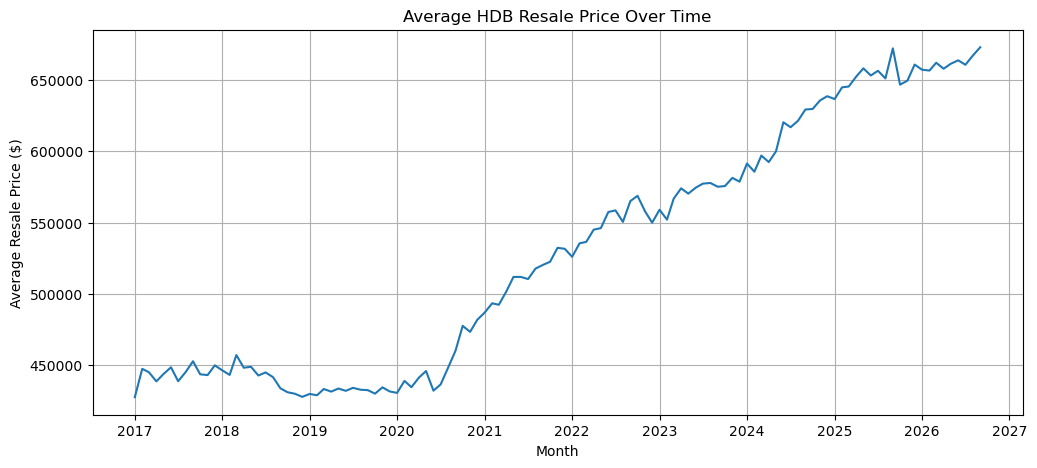

In [10]:
import matplotlib.pyplot as plt

monthly_avg = df.groupby('month')['resale_price'].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_avg.index, monthly_avg.values)
plt.title('Average HDB Resale Price Over Time')
plt.xlabel('Month')
plt.ylabel('Average Resale Price ($)')
plt.grid(True)
plt.show()

<h2 style="color: blue;">Price by town (bar chart)</h2>

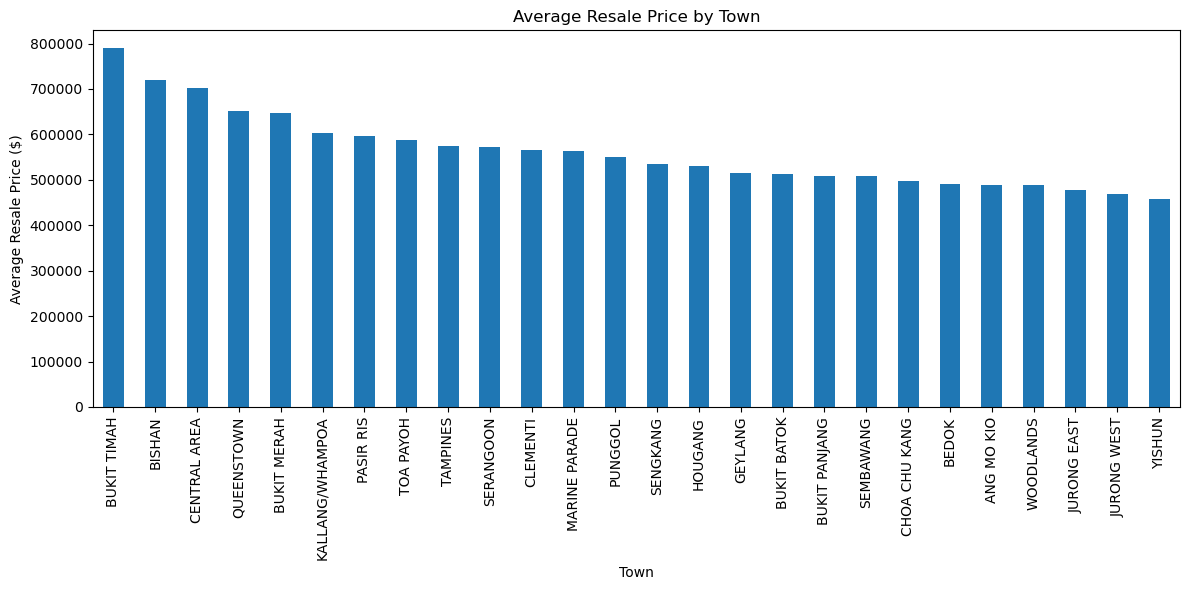

In [11]:
town_avg = df.groupby('town')['resale_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
town_avg.plot(kind='bar')
plt.title('Average Resale Price by Town')
plt.xlabel('Town')
plt.ylabel('Average Resale Price ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<h2 style="color: blue;">Price by flat type </h2>

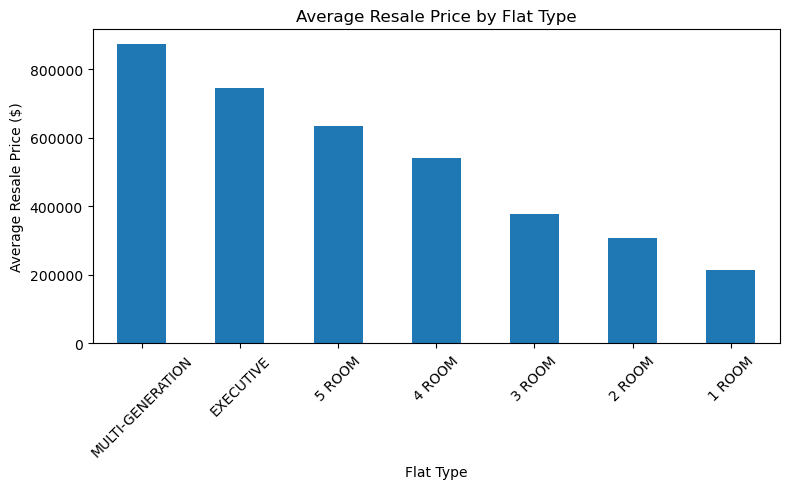

In [12]:
flat_avg = df.groupby('flat_type')['resale_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
flat_avg.plot(kind='bar')
plt.title('Average Resale Price by Flat Type')
plt.xlabel('Flat Type')
plt.ylabel('Average Resale Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h2 style="color: blue;">Price by storey range </h2>

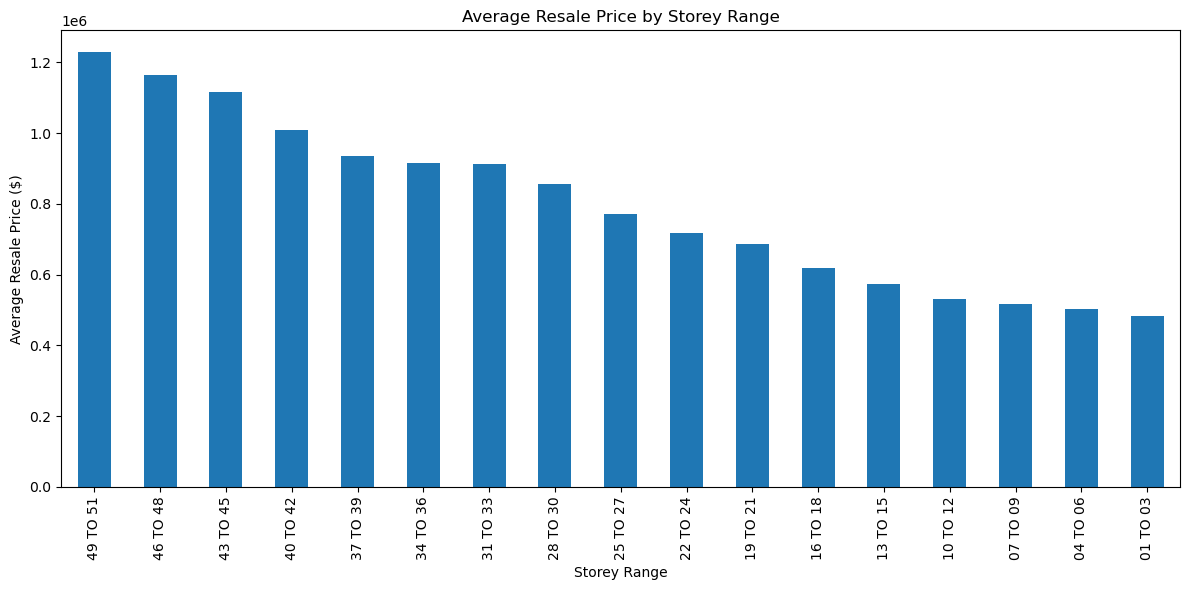

In [13]:
storey_avg = df.groupby('storey_range')['resale_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
storey_avg.plot(kind='bar')
plt.title('Average Resale Price by Storey Range')
plt.xlabel('Storey Range')
plt.ylabel('Average Resale Price ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<h2 style="color: blue;">Price by remaining lease (scatter plot) </h2>

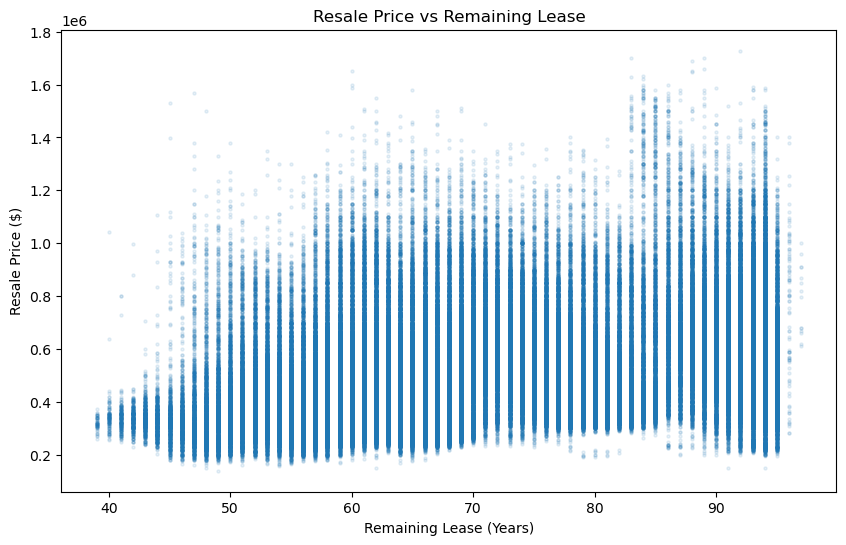

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(df['remaining_lease_years'], df['resale_price'], alpha=0.1, s=5)
plt.title('Resale Price vs Remaining Lease')
plt.xlabel('Remaining Lease (Years)')
plt.ylabel('Resale Price ($)')
plt.show()

<h2 style="color: blue;">Correlation heatmap </h2>

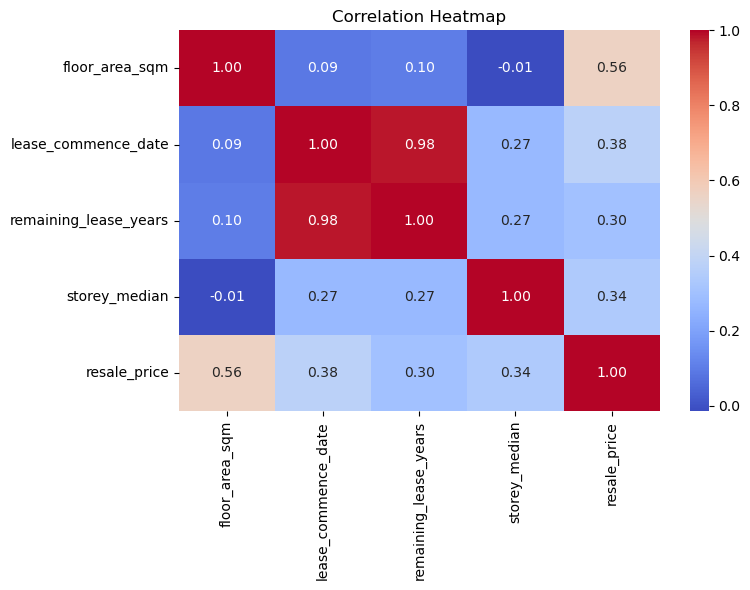

In [15]:
import seaborn as sns

numeric_cols = ['floor_area_sqm', 'lease_commence_date', 'remaining_lease_years', 'storey_median', 'resale_price']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

<h2 style="color: blue;"> Feature engineering </h2>

In [18]:
df_model = pd.get_dummies(df, columns=['town', 'flat_type', 'flat_model'], drop_first=True)

feature_cols = [col for col in df_model.columns if col not in
                ['month', 'block', 'street_name', 'storey_range', 'remaining_lease', 'resale_price']]

X = df_model[feature_cols]
y = df_model['resale_price']

<h2 style="color: blue;"> Train/test split </h2>

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(192454, 55) (48114, 55)


<h2 style="color: blue;"> Build XGBoost model </h2>

In [20]:
import xgboost as xgb

model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


<h2 style="color: blue;"> Evaluate model </h2>

In [21]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")

MSE: 2,127,672,479.43
RMSE: 46,126.70
R²: 0.9419


<h2 style="color: blue;"> Plot actual vs predicted </h2>

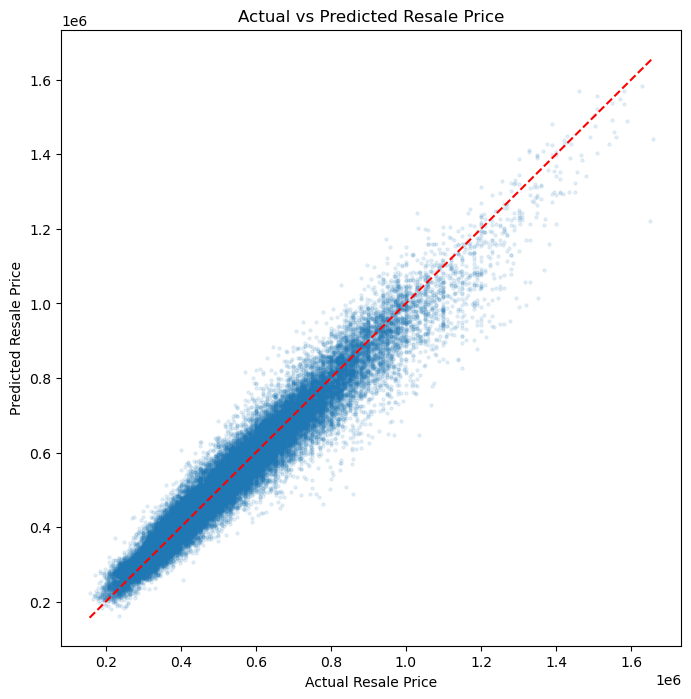

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.1, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Resale Price')
plt.ylabel('Predicted Resale Price')
plt.title('Actual vs Predicted Resale Price')
plt.show()

<h2 style="color: blue;"> SHAP explainability </h2>

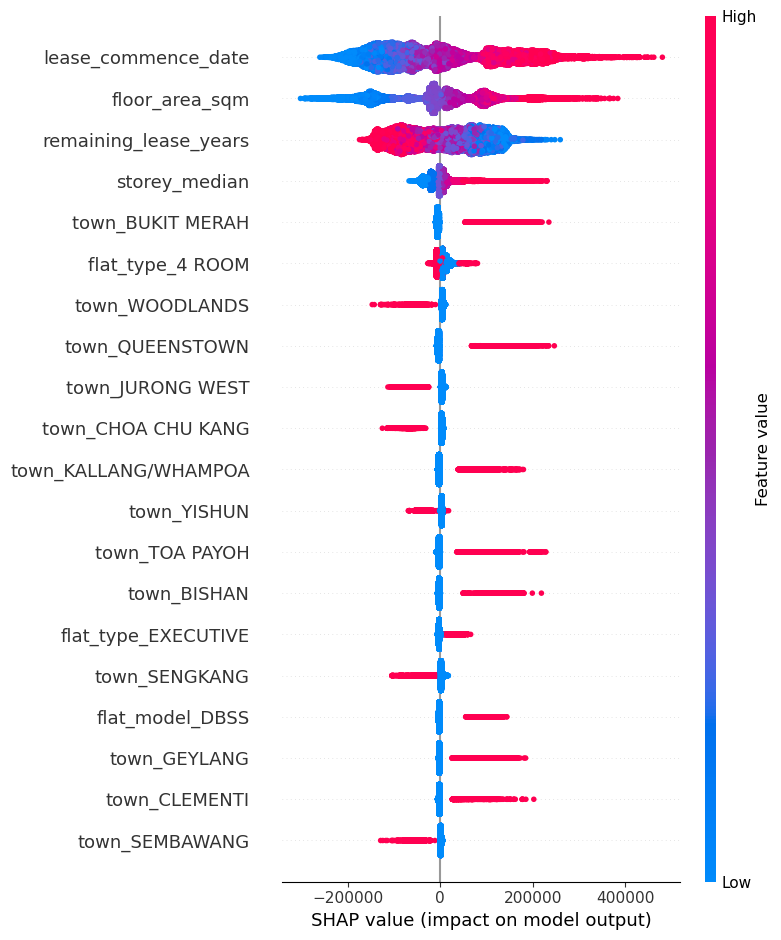

In [23]:
!pip install shap

import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

<h2 style="color: blue;"> Summarise findings — markdown cell </h2>

## Findings

- Model performance: R² = [fill in], RMSE = [fill in]
- Top features driving resale price: [fill in from SHAP plot — likely floor area, storey, town, remaining lease]
- [Add 2–3 sentences on what this means]

In [24]:
import pickle

pickle.dump(model, open('xgb_model.pkl', 'wb'))